<img src="https://github.com/KartikNW/MSDS_458_Public/blob/main/images2/NorthwesternHeader.png?raw=1" />

In [1]:
NOTEBOOK_VERSION = "1.0"
QUARTER = "Spring 2026"

from datetime import datetime
NOTEBOOK_START_TIME = datetime.now()
print(f"Notebook Version: {NOTEBOOK_VERSION} | {QUARTER}")

Notebook Version: 1.0 | Spring 2026


# Assignment 3 — Part B: Exploring Pretrained Models for Text-to-Code Generation

## 🎯 Learning Objectives

By the end of this notebook, you will:

- Understand the power of **pretrained models** for code generation
- Load and use **CodeT5**, a pretrained encoder-decoder model for code
- Evaluate a pretrained model's **zero-shot** performance (without fine-tuning)
- Compare zero-shot performance with Part A's from-scratch model
- Understand BLEU scores and syntax validity metrics for code quality
- (Optional) Explore other pretrained models like CodeGen or StarCoder

## 📊 Comparison with Part A

**Part A (From Scratch):**
- Built transformer from scratch (2 layers, 256 dim, ~1M parameters)
- Trained on 374-500 examples
- Test accuracy: ~56-89% token-level
- **BLEU Score**: 0.77 (essentially zero)
- **Syntax Validity**: 0%
- Generation: Poor (random fragments)

**Part B (Pretrained - Zero-Shot):**
- Use CodeT5+ 220M Python (220M parameters, pretrained on code + Python-tuned)
- **No task-specific training** - test immediately
- Expected: Much better than from-scratch due to pretraining
- This establishes the value of transfer learning!

## Notebook Overview

- 🧩 Step 1: Setup and Imports
- 📦 Step 1B: Import Shared Utilities
- 🗂️ Step 2: Load and Process MBPP Dataset
- 🤖 Step 4: Load Pretrained CodeT5+ Model
- 🧪 Step 5: Zero-Shot Evaluation
- 📊 Step 5B: BLEU Evaluation of Zero-Shot CodeT5+
- 📊 Step 6: Comparison with Part A (From Scratch)

## 🧩 Step 1: Setup and Imports

In this step, you will import all necessary libraries:

- **Transformers** - Hugging Face library for pretrained models (CodeT5)
- **Datasets** - For loading MBPP
- **TensorFlow/Keras** - Backend for CodeT5 model
- **Evaluation metrics** - To measure code generation quality

In [2]:
# Install required packages (run this in Colab or local environment)
# Note: tf-keras is required because Transformers doesn't yet support Keras 3
# Uncomment the line below if running on Colab or if packages are not installed
!pip3 install -q "transformers>=4.47.0,<5.0" datasets tf-keras evaluate torch

print("✅ Packages already installed via uv!")

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
✅ Packages already installed via uv!


In [3]:
# Core dependencies
import tensorflow as tf
# Disable Metal GPU locally — T5 beam search uses XLA ops unsupported by Metal plugin
# (Colab uses CUDA which supports these ops fine)
import sys
if sys.platform == 'darwin':
    tf.config.set_visible_devices([], 'GPU')
import tf_keras as keras  # Use tf-keras (Keras 2) instead of Keras 3
from transformers import (
    TFAutoModelForSeq2SeqLM,
    AutoTokenizer,
)
from datasets import load_dataset
import numpy as np
import pandas as pd
import evaluate
import os
import random
from tqdm import tqdm

# For reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 2.19.0


## 📦 Step 1B: Import Shared Utilities

This cell automatically downloads `assignment3_utils.py` if running in Google Colab or if the file is missing locally.

The utilities module provides:
- **Configuration**: MBPP dataset loading and processing
- **Data Loading**: Functions to load and extract dataset examples
- **Data Processing**: Functions to prepare training data
- **BLEU Evaluation**: Functions to evaluate model performance

**Note**: This works seamlessly in both local Jupyter and Google Colab environments.

In [4]:
import os, sys, urllib.request

IN_COLAB = 'google.colab' in sys.modules
UTILS_BRANCH = "Spring_2026"  # "main" for release

def fetch_github_raw(user, repo, branch, file_path, local_path):
    url = f"https://raw.githubusercontent.com/{user}/{repo}/{branch}/{file_path}"
    urllib.request.urlretrieve(url, local_path)
    print(f"Fetched {file_path} from branch '{branch}'.")

if IN_COLAB:
    if not os.path.exists("assignment3_utils.py"):
        fetch_github_raw("KartikNW", "MSDS_458_Public", UTILS_BRANCH,
            "MSDS458_Assignment_03/assignment3_utils.py", "assignment3_utils.py")
else:
    print("Using local assignment3_utils.py")

# Import utilities (Note: DATASET is defined in this notebook, not imported)
from assignment3_utils import (
    # Data loading & processing
    prepare_training_data,
    # BLEU evaluation
    add_python_hint,
    compute_bleu_for_code,
    evaluate_model_with_bleu,
    analyze_bleu_results,
    # Batch generation
    batch_generate_codes,
)

print("✅ Utilities imported successfully")

Using local assignment3_utils.py
✅ assignment3_utils v1.0.0 loaded successfully
✅ Utilities imported successfully


## 🗂️ Step 2: Load and Process MBPP Dataset

In this step, you will:

- Load MBPP (Mostly Basic Python Problems) dataset
- Extract problem descriptions and Python solutions
- Process data into train/validation/test splits

MBPP contains 974 Python programming problems:
- **Train**: 374 examples
- **Validation**: 90 examples
- **Test**: 50 examples

In [5]:
# ========================================
# LOAD AND PROCESS MBPP DATASET
# ========================================

print("Loading and processing MBPP dataset...")
print("This uses shared utilities from assignment3_utils.py")
print("=" * 60)

# Load and process all splits using shared utility
data = prepare_training_data("MBPP")

# Extract data into variables (maintaining compatibility with rest of notebook)
train_prompts = data['train']['prompts']
train_code = data['train']['code']

val_prompts = data['val']['prompts']
val_code = data['val']['code']

test_prompts = data['test']['prompts']
test_code = data['test']['code']

print("=" * 60)
print(f"📊 Dataset sizes:")
print(f"  Train: {len(train_prompts)}")
print(f"  Val: {len(val_prompts)}")
print(f"  Test: {len(test_prompts)}")
print("✅ Dataset loaded and processed successfully!")

Loading and processing MBPP dataset...
This uses shared utilities from assignment3_utils.py
Processing MBPP dataset...
  Train: 374 examples
  Val: 90 examples
  Test: 50 examples
📊 Dataset sizes:
  Train: 374
  Val: 90
  Test: 50
✅ Dataset loaded and processed successfully!


## 🤖 Step 4: Load Pretrained CodeT5+ Model

In this step, you will:

- Load **CodeT5+ 220M Python** - a 220M parameter model pretrained on code
- Load the corresponding tokenizer
- Understand the model architecture

**CodeT5+ (Python variant)** was trained on:
- Large-scale code corpus with improved pretraining objectives
- Multiple programming languages, then fine-tuned on Python
- Advanced tasks: span denoising, causal LM, contrastive learning, text-code matching

This gives it a strong foundation for Python code generation!

In [6]:
# ========================================
# LOAD CODET5 MODEL AND TOKENIZER
# ========================================

MODEL_NAME = "Salesforce/codet5p-220m-py"  # --- EXPERIMENT HERE: try other models (codet5-base, codet5p-770m, etc.) ---

print(f"Loading pretrained model: {MODEL_NAME}")
print("This may take a few minutes on first run (downloads ~250MB)...")
print("Note: CodeT5+ is an improved version of CodeT5 with better pretraining")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load pretrained model
# Try loading TensorFlow weights directly first (no PyTorch conversion needed)
try:
    model = TFAutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    print("✅ Loaded from TensorFlow weights")
except Exception as e:
    print(f"TensorFlow weights not available, trying PyTorch conversion...")
    print(f"Note: This requires PyTorch to be installed")
    model = TFAutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME, from_pt=True)

print(f"\n✅ Model and tokenizer loaded!")
print(f"Model type: {type(model).__name__}")
print(f"Tokenizer vocab size: {tokenizer.vocab_size:,}")
print(f"Model parameters: ~220M")

Loading pretrained model: Salesforce/codet5p-220m-py
This may take a few minutes on first run (downloads ~250MB)...
Note: CodeT5+ is an improved version of CodeT5 with better pretraining


TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


TensorFlow weights not available, trying PyTorch conversion...
Note: This requires PyTorch to be installed


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFT5ForConditionalGeneration: ['encoder.embed_tokens.weight', 'lm_head.weight', 'decoder.embed_tokens.weight']
- This IS expected if you are initializing TFT5ForConditionalGeneration from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFT5ForConditionalGeneration from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFT5ForConditionalGeneration were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFT5ForConditionalGeneration for predictions without further training.



✅ Model and tokenizer loaded!
Model type: TFT5ForConditionalGeneration
Tokenizer vocab size: 32,100
Model parameters: ~220M


In [7]:
# ========================================
# TEST TOKENIZER ON SAMPLE
# ========================================

# Get a sample from training data
sample_prompt = train_prompts[0]
sample_code = train_code[0]

print("Sample prompt:")
print(sample_prompt[:150] + "...")
print("\nSample code:")
print(sample_code[:150] + "...")

# Tokenize
inputs = tokenizer(sample_prompt, return_tensors="tf", truncation=True, max_length=128)
targets = tokenizer(sample_code, return_tensors="tf", truncation=True, max_length=256)

print(f"\nTokenized input shape: {inputs['input_ids'].shape}")
print(f"Tokenized target shape: {targets['input_ids'].shape}")
print(f"\nFirst 20 input tokens: {inputs['input_ids'][0, :20].numpy()}")
print(f"Decoded back: {tokenizer.decode(inputs['input_ids'][0, :20], skip_special_tokens=False)}")

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


Sample prompt:
Write a function to find the longest chain which can be formed from the given set of pairs....

Sample code:
class Pair(object): 
	def __init__(self, a, b): 
		self.a = a 
		self.b = b 
def max_chain_length(arr, n): 
	max = 0
	mcl = [1 for i in range(n)...

Tokenized input shape: (1, 21)
Tokenized target shape: (1, 191)

First 20 input tokens: [    1  3067   279   445   358  1104   326 12163  2687  1492   848   506
 20010   628   326   864   444   434  5574    18]
Decoded back: <s>Write a function to find the longest chain which can be formed from the given set of pairs.


## 🧪 Step 5: Zero-Shot Evaluation

In this step, you will test the **pretrained CodeT5 model without any fine-tuning**.

This is called **zero-shot** evaluation because:
- The model has never seen MBPP during training
- We're testing its ability to generate code based only on its pretraining
- This establishes a baseline for comparison with fine-tuned models

**What to expect:**
- CodeT5 was pretrained on millions of code examples from GitHub
- It should have some basic understanding of Python syntax and patterns
- Performance may be limited for specific task formats (like MBPP prompts)
- Fine-tuning (in Part C) should significantly improve task-specific performance

In [8]:
# ========================================
# DEFINE GENERATION FUNCTION
# ========================================

def generate_code(prompt, max_length=256, num_beams=5):  # --- EXPERIMENT HERE: max_length, num_beams ---
    """
    Generate code from a natural language prompt using CodeT5.

    Args:
        prompt: Natural language description of the task
        max_length: Maximum length of generated code
        num_beams: Number of beams for beam search (higher = better but slower)

    Returns:
        Generated code as a string
    """
    # Tokenize input
    inputs = tokenizer(
        prompt,
        return_tensors="tf",
        truncation=True,
        max_length=128
    )

    # Generate with beam search
    outputs = model.generate(
        inputs['input_ids'],
        max_length=max_length,
        num_beams=num_beams,
        early_stopping=True,
        no_repeat_ngram_size=2,  # Prevent repetition
    )

    # Decode generated tokens
    generated_code = tokenizer.decode(outputs[0], skip_special_tokens=True)

    return generated_code

print("✅ Generation function defined")

✅ Generation function defined


In [9]:
# ========================================
# TEST ZERO-SHOT GENERATION ON SAMPLES
# ========================================

print("🧪 Testing zero-shot code generation on MBPP test examples...")
print("=" * 80)

# Test on first 3 test examples
num_samples = 3

for i in range(num_samples):
    print(f"\n{'='*80}")
    print(f"Example {i+1}/{num_samples}")
    print(f"{'='*80}")

    prompt = test_prompts[i]
    expected_code = test_code[i]

    print(f"\n📝 Prompt:")
    print(prompt[:200] + ("..." if len(prompt) > 200 else ""))

    print(f"\n🎯 Expected code:")
    print(expected_code[:200] + ("..." if len(expected_code) > 200 else ""))

    print(f"\n🤖 Generated code (zero-shot):")
    generated = generate_code(prompt)
    print(generated[:200] + ("..." if len(generated) > 200 else ""))

print(f"\n{'='*80}")
print("✅ Zero-shot evaluation complete!")

🧪 Testing zero-shot code generation on MBPP test examples...

Example 1/3

📝 Prompt:
Write a python function to remove first and last occurrence of a given character from the string.

🎯 Expected code:
def remove_Occ(s,ch): 
    for i in range(len(s)): 
        if (s[i] == ch): 
            s = s[0 : i] + s[i + 1:] 
            break
    for i in range(len(s) - 1,-1,-1):  
        if (s[i] == ...

🤖 Generated code (zero-shot):


I0000 00:00:1773447156.853005 56688063 service.cc:152] XLA service 0x8befe7e00 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773447156.853023 56688063 service.cc:160]   StreamExecutor device (0): Host, Default Version
2026-03-13 17:12:36.855199: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773447156.888595 56688063 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.




def remove_first_last(s):
    return s[0:-1] + s[-1:]

Example 2/3

📝 Prompt:
Write a function to sort a given matrix in ascending order according to the sum of its rows.

🎯 Expected code:
def sort_matrix(M):
    result = sorted(M, key=sum)
    return result

🤖 Generated code (zero-shot):


def sort_matrix(matrix):
    sum_of_rows = sum([row[0] for row in matrix]) 
    matrix.sort(key=lambda row: sum(row), reverse=True)
    
matrix = [[1,2,3,4,5],[6,7,8,9,10], [11,12,13,14,15]]
print(f...

Example 3/3

📝 Prompt:
Write a function to count the most common words in a dictionary.

🎯 Expected code:
from collections import Counter
def count_common(words):
  word_counts = Counter(words)
  top_four = word_counts.most_common(4)
  return (top_four)


🤖 Generated code (zero-shot):


def count_most_common_words(dictionary):
    words = set(word for word in dictionary.keys() if dictionary[word] > 0.5)
	return len(words)

✅ Zero-shot evaluation complete!


## 📊 Step 5B: BLEU Evaluation of Zero-Shot CodeT5+

Now let's **quantitatively evaluate** the zero-shot model using BLEU score and syntax validity.

This establishes a baseline to compare with:
- **Part A (From Scratch)**: BLEU 0.77, 0% syntax validity
- **Part C (Fine-Tuned)**: To be measured after fine-tuning in next notebook

We'll use the same evaluation methodology as Part A for fair comparison.

**Performance note:** We use **batch generation** (multiple prompts at once) with
**greedy decoding** for faster evaluation. The 3-sample demo above used beam search
to show that technique; here speed matters more since we evaluate all 50 test examples.

⚡ Generating all test codes in batches (greedy decoding for speed)...


Batch generation: 100%|██████████| 7/7 [02:48<00:00, 24.11s/it]


🔬 Scoring ZERO-SHOT CODET5+ on 50 test examples (pre-generated)...


Zero-Shot CodeT5+ BLEU Evaluation: 100%|██████████| 50/50 [00:00<00:00, 368.32it/s]



📊 ZERO-SHOT CODET5+ EVALUATION RESULTS
BLEU Score (mean):        4.24
BLEU Score (median):      0.00
BLEU Score (std dev):     6.52
BLEU Score (min):         0.00
BLEU Score (max):         26.84
Syntax Validity:          22/50 (44.0%)

✅ Zero-Shot CodeT5+ evaluation complete!

📊 DETAILED ANALYSIS: ZERO-SHOT CODET5+


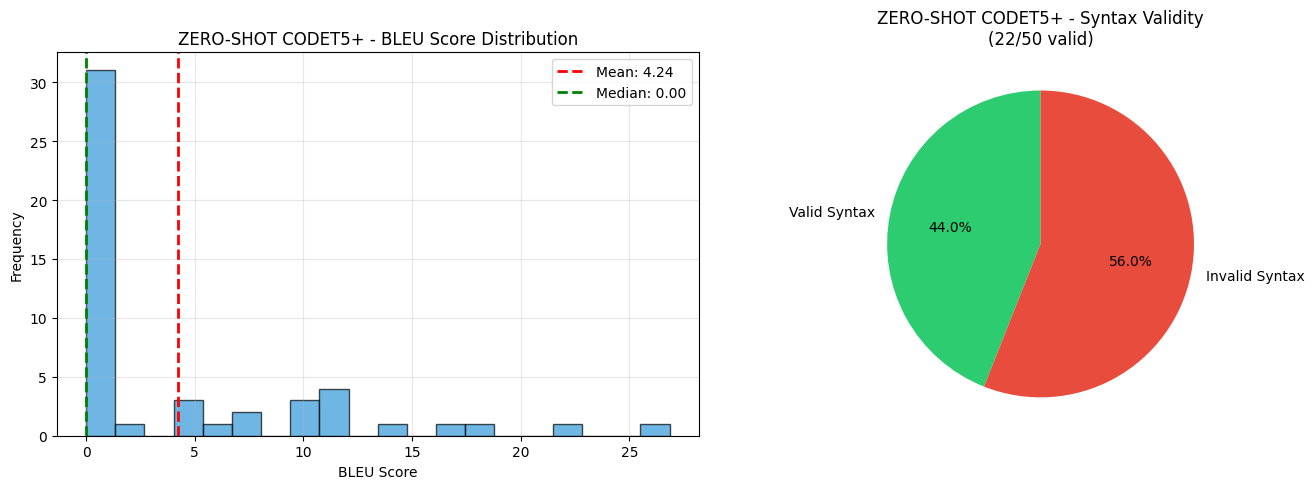


🏆 BEST ZERO-SHOT CODET5+ EXAMPLES (Highest BLEU)

Rank #1 - Example 12
BLEU Score: 26.84
Syntax Valid: False

📝 Prompt:
Python:
Write a function to find the first duplicate element in a given array of integers.

🎯 Reference:
def find_first_duplicate(nums):
    num_set = set()
    no_duplicate = -1

    for i in range(len(nums)):

        if nums[i] in num_set:
     ...

🤖 Generated (Zero-Shot CodeT5+):


Example:
Input: [1,2,3,4,5,6,7,8,9,10]
Output: 1
Explanation: The first duplicate element in the array is 1.
"""
class Solution: 
    def firstDupli...

Rank #2 - Example 4
BLEU Score: 21.49
Syntax Valid: True

📝 Prompt:
Write a python function to find the volume of a triangular prism.

🎯 Reference:
def find_Volume(l,b,h) : 
    return ((l * b * h) / 2) 

🤖 Generated (Zero-Shot CodeT5+):


def volume(a, b, c):
    return (a*b*c)/(2*a)


Rank #3 - Example 31
BLEU Score: 17.53
Syntax Valid: False

📝 Prompt:
Python:
Write a function to filter even numbers using lambda function.

🎯 Refere

In [10]:
# ========================================
# ZERO-SHOT BLEU EVALUATION
# ========================================

import evaluate

# Load BLEU metric
bleu_metric = evaluate.load("bleu")

# Apply Python hints to test prompts (helps CodeT5 generate Python instead of other languages)
test_prompts_python = [add_python_hint(p) for p in test_prompts]

print("⚡ Generating all test codes in batches (greedy decoding for speed)...")
zeroshot_generated = batch_generate_codes(  # --- EXPERIMENT HERE: batch_size, max_length, num_beams ---
    test_prompts_python,
    model=model,
    tokenizer=tokenizer,
)

# Score pre-generated codes (no inference needed — fast)
zeroshot_bleu_scores, zeroshot_syntax_valid, zeroshot_codes, zeroshot_stats = evaluate_model_with_bleu(
    test_prompts_python,
    test_code,
    None,  # generate_fn not needed — using pre-generated codes
    bleu_metric,
    model_label="Zero-Shot CodeT5+",
    generated_codes=zeroshot_generated,
)

# Analyze results with visualizations
analyze_bleu_results(
    zeroshot_bleu_scores,
    zeroshot_syntax_valid,
    zeroshot_codes,
    test_prompts_python,
    test_code,
    zeroshot_stats,
    model_label="Zero-Shot CodeT5+"
)

## 📊 Step 6: Comparison with Part A (From Scratch)

Let's compare the zero-shot pretrained model with the from-scratch model from Part A:

📊 COMPARISON: From-Scratch vs Pretrained (Zero-Shot)

Metric                         Part A (From Scratch)     Part B (Zero-Shot)        Improvement    
-----------------------------------------------------------------------------------------------
BLEU Score (mean)              0.96                      4.24                      4.4            x
Syntax Validity %              0.0                       44.0                      +44.0           pp
Model Size                     ~1M params                220M params               220x           
Training Examples              374 (MBPP)                Large-scale code          ~10,000x+      


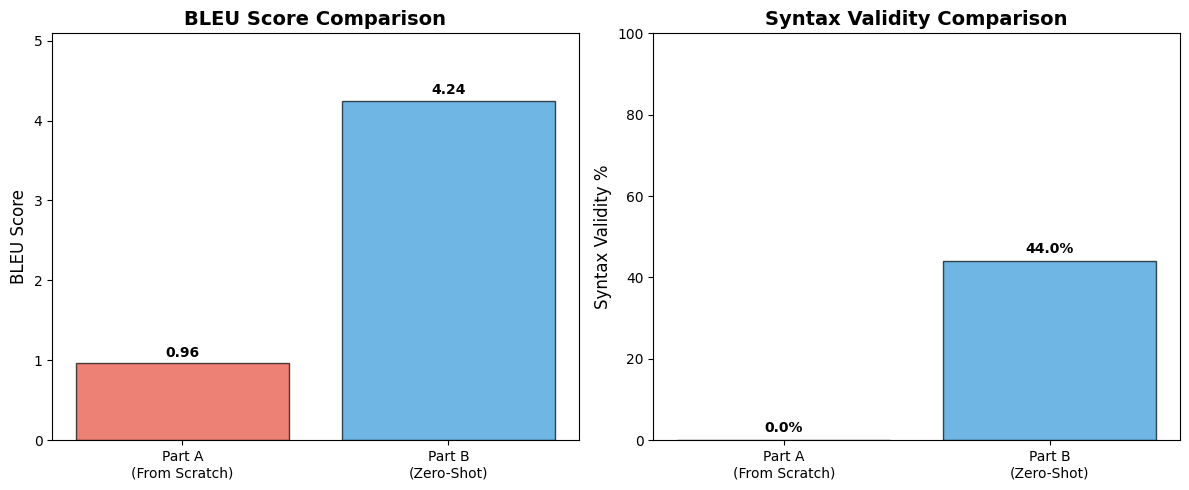


✅ Comparison complete!


In [11]:
# ========================================
# COMPARE WITH PART A RESULTS
# ========================================

# Part A results (from Assignment3_PartA_Transformer)
part_a_bleu = 0.96
part_a_syntax = 0.0  # 0%

# Part B zero-shot results (just measured)
part_b_bleu = zeroshot_stats['mean']
part_b_syntax = zeroshot_stats['syntax_valid_pct']

print("=" * 80)
print("📊 COMPARISON: From-Scratch vs Pretrained (Zero-Shot)")
print("=" * 80)
print(f"\n{'Metric':<30} {'Part A (From Scratch)':<25} {'Part B (Zero-Shot)':<25} {'Improvement':<15}")
print("-" * 95)
print(f"{'BLEU Score (mean)':<30} {part_a_bleu:<25.2f} {part_b_bleu:<25.2f} {part_b_bleu/part_a_bleu if part_a_bleu > 0 else float('inf'):<15.1f}x")
print(f"{'Syntax Validity %':<30} {part_a_syntax:<25.1f} {part_b_syntax:<25.1f} {'+' + str(part_b_syntax - part_a_syntax):<15} pp")
print(f"{'Model Size':<30} {'~1M params':<25} {'220M params':<25} {'220x':<15}")
print(f"{'Training Examples':<30} {'374 (MBPP)':<25} {'Large-scale code':<25} {'~10,000x+':<15}")
print("=" * 95)

# Visualization
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# BLEU comparison
models = ['Part A\n(From Scratch)', 'Part B\n(Zero-Shot)']
bleu_scores = [part_a_bleu, part_b_bleu]
colors = ['#e74c3c', '#3498db']

ax1.bar(models, bleu_scores, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('BLEU Score', fontsize=12)
ax1.set_title('BLEU Score Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(bleu_scores) * 1.2)
for i, v in enumerate(bleu_scores):
    ax1.text(i, v + max(bleu_scores)*0.02, f'{v:.2f}', ha='center', fontweight='bold')

# Syntax validity comparison
syntax_scores = [part_a_syntax, part_b_syntax]

ax2.bar(models, syntax_scores, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Syntax Validity %', fontsize=12)
ax2.set_title('Syntax Validity Comparison', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
for i, v in enumerate(syntax_scores):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✅ Comparison complete!")

## 📊 Summary and Next Steps

### What You Learned

✅ **Pretrained models outperform from-scratch** even without task-specific training
✅ **Transfer learning works**: Large-scale pretraining provides strong foundation
✅ **BLEU + syntax validity** measure code quality better than token accuracy
✅ **Zero-shot has limitations**: Valid syntax but may miss task-specific patterns

### Key Takeaway

Pretraining (large-scale) >> Training from scratch (374 examples), but fine-tuning (Part C) will combine both advantages.

### Next Steps

**Proceed to Part C** (`Assignment3_PartC_Finetuning.ipynb`) to:
- Fine-tune CodeT5+ on MBPP
- See the complete three-way comparison
- Learn the production workflow

**Save your results** for Part C comparison:
- Zero-shot BLEU: `{zeroshot_stats['mean']:.2f}`
- Zero-shot syntax validity: `{zeroshot_stats['syntax_valid_pct']:.1f}%`

**Optional**: Try other models (CodeGen, StarCoder) by changing `MODEL_NAME` in Step 4 and re-running evaluation

In [12]:
NOTEBOOK_END_TIME = datetime.now()
elapsed = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
total_mins, total_secs = divmod(int(elapsed.total_seconds()), 60)
print(f"✅ Notebook complete")
print(f"Total time:  {total_mins}m {total_secs}s")
print(f"Current time: {NOTEBOOK_END_TIME.strftime('%Y-%m-%d %H:%M:%S')}")

✅ Notebook complete
Total time:  3m 28s
Current time: 2026-03-13 17:15:52
